## Getting Tiny ImageNet Dataset

In [ ]:
# Wichita State University, Fall 2025 
# Submitted by Chandra Parasa

import os
import random
import numpy as np
from PIL import Image

# Mounting Google Drive to access dataset stored there
from google.colab import drive
drive.mount('/content/drive')  # This will prompt for authorization

# Define paths for the dataset
# Location of the zipped Tiny ImageNet dataset on Google Drive
ZIP_PATH = "/content/drive/MyDrive/tiny-imagenet-200.zip"

# Local path where the dataset will be extracted
EXTRACTED_DIR = "/content/tiny-imagenet-200"

# Root directory for working with the dataset
DATASET_ROOT = "/content/tiny-imagenet-200"

# Output directory to save processed data or subsets
OUT_ROOT = "/content/drive/MyDrive/my_tinyimagenet"

# Extract the dataset if it hasn't been extracted already
# Check if the dataset folder already exists
if not os.path.exists(EXTRACTED_DIR):
    print("Extracting dataset from Google Drive...")

    # Check if the ZIP file exists in the specified location
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(f"ZIP file not found at {ZIP_PATH}. Please upload it to your Drive first.")

    # Extract the zip file quietly (without printing all file names)
    !unzip -q "{ZIP_PATH}" -d /content/
    print("Dataset extracted to /content/tiny-imagenet-200")
else:
    # If the dataset is already extracted, notify the user
    print("Dataset already extracted in /content")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted in /content


## Creating own Dataset from the Tiny ImageNet Dataset

### Considering Only 100 Classes from the Dataset

In [7]:
# Setting random seeds for reproducibility
# This ensures that any random operations (like sampling classes) produce the same results every time the code runs
random.seed(42)
np.random.seed(42)

# Get all class folders from the 'train' directory
# In Tiny ImageNet, the training directory contains 200 subfolders, each representing a class
all_train_classes = sorted(os.listdir(os.path.join(DATASET_ROOT, 'train')))

# Sanity check: Ensure there are exactly 200 classes in the training directory
assert len(all_train_classes) == 200, "Expected 200 classes in Tiny ImageNet train directory"

# Randomly select 100 classes out of the 200 available classes
# This subset can be used to create a smaller dataset for experiments or faster training
selected_classes = random.sample(all_train_classes, 100)

# Sort the selected classes alphabetically for consistent ordering
# This helps keep results reproducible and organized
selected_classes.sort()

# Print information about the selected classes
# Confirm number of classes selected
print(f"Selected {len(selected_classes)} classes out of 200.")
# Show first 5 class names as a quick preview
print(f"Sample classes: {selected_classes[:5]} ...")


Selected 100 classes out of 200.
Sample classes: ['n01629819', 'n01698640', 'n01768244', 'n01770393', 'n01774384'] ...


### From Each Class, taking 500 Images & Splitting Dataset into Training, Validation, and Test Sets

In [ ]:
#  Initialize lists to store dataset splits
# These lists will hold tuples of (image_path, label) for each split
train_data = []
val_data = []
test_data = []

#  Mapping class names to numeric labels
# Each selected class gets a unique integer label for model training
class_to_label = {cls_name: idx for idx, cls_name in enumerate(selected_classes)}

#  Build class-balanced dataset splits
# Loop through each selected class to prepare train/val/test sets
for class_name in selected_classes:
    # Path to images for this class
    class_img_dir = os.path.join(DATASET_ROOT, 'train', class_name, 'images')

    # Get all image filenames ending with '.JPEG'
    image_files = [f for f in os.listdir(class_img_dir) if f.endswith('.JPEG')]

    # Ensure there are at least 500 images in this class
    if len(image_files) < 500:
        raise ValueError(f"Class {class_name} has only {len(image_files)} images (<500)")

    # Shuffle the image list randomly to avoid any ordering bias
    random.shuffle(image_files)

    # Select exactly 500 images per class
    selected_images = image_files[:500]

    # Get numeric label for this class
    label = class_to_label[class_name]

    # Split images into train, validation, and test 
    # 300 images for training, 100 for validation, 100 for testing - ensures no duplicate images in 3 datasets 
    train_imgs = selected_images[:300]
    val_imgs   = selected_images[300:400]
    test_imgs  = selected_images[400:500]

    # Add full image paths along with their labels to respective lists
    train_data.extend([(os.path.join(class_img_dir, f), label) for f in train_imgs])
    val_data.extend([(os.path.join(class_img_dir, f), label) for f in val_imgs])
    test_data.extend([(os.path.join(class_img_dir, f), label) for f in test_imgs])

#  Verify that the splits have the expected number of images
print(f"Training images:   {len(train_data)}")      #  100 classes * 300 = 30,000
print(f"Validation images: {len(val_data)}")        #  100 classes * 100 = 10,000
print(f"Test images:       {len(test_data)}")       # 100 classes * 100 = 10,000

# Ensure the splits are exactly as expected
assert len(train_data) == 30000, "Train count mismatch"
assert len(val_data) == 10000, "Validation count mismatch"
assert len(test_data) == 10000, "Test count mismatch"

print("Class-balanced split completed successfully.")


Training images:   30000
Validation images: 10000
Test images:       10000
Class-balanced split completed successfully.


### Preparing Data for the Model as described in Section 2 of the AlexNet Paper

In [9]:
#  Data Processing for AlexNet using PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

#  Define normalization values for AlexNet
# These are the standard mean and std values used for pretrained AlexNet models
# They help scale image pixel values to a range suitable for the network
alexnet_mean = [0.485, 0.456, 0.406]
alexnet_std  = [0.229, 0.224, 0.225]

#  Define transformations for training data
# These transformations augment the data and normalize it
train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),       # Randomly crop 64x64 patches with padding of 4 pixels
    transforms.RandomHorizontalFlip(),          # Randomly flip images horizontally for augmentation
    transforms.ToTensor(),                      # Convert PIL image to PyTorch tensor (C x H x W)
    transforms.Normalize(mean=alexnet_mean, std=alexnet_std)  # Normalize using AlexNet mean and std
])

#  Define transformations for validation and test data
# No augmentation here; just convert to tensor and normalize
test_val_transform = transforms.Compose([
    transforms.ToTensor(),                      # Convert image to tensor
    transforms.Normalize(mean=alexnet_mean, std=alexnet_std)  # Normalize using AlexNet mean and std
])


## Saving dataset in the form of images and .npy files

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from PIL import Image  # Make sure PIL is imported for image loading

#  Define output directory for saving images by split
IMG_OUT_ROOT = os.path.join(OUT_ROOT, 'images_by_split')

# Create subdirectories for each dataset split if they don't exist
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(IMG_OUT_ROOT, split), exist_ok=True)

#  Function to save images and corresponding .npy arrays
def save_images_and_arrays(data_list, split_name, transform=None):
    """
    Save images into folders organized by class and also save corresponding numpy arrays.

    Args:
        data_list (list): List of tuples (image_path, label)
        split_name (str): 'train', 'val', or 'test'
        transform (torchvision.transforms, optional): Transform to apply before saving .npy arrays
    """
    images_np = []  # To store raw pixel values of all images
    labels_np = []  # To store numeric labels

    split_dir = os.path.join(IMG_OUT_ROOT, split_name)

    # Loop through each image in the dataset split
    for img_path, label in data_list:
        # Load the image and convert to RGB
        img = Image.open(img_path).convert('RGB')

        # Convert image to numpy array (H x W x C) and store
        img_array = np.array(img, dtype=np.float32)
        images_np.append(img_array)
        labels_np.append(label)

        # Save image into folder corresponding to its class
        class_dir = os.path.join(split_dir, f"class_{label:03d}")  # e.g., class_005
        os.makedirs(class_dir, exist_ok=True)
        img_name = os.path.basename(img_path).replace('.JPEG', '.png')  # Convert extension to PNG
        img.save(os.path.join(class_dir, img_name))

    # Stack all images into a single numpy array (N,H,W,C)
    images_np = np.stack(images_np, axis=0)
    labels_np = np.array(labels_np, dtype=np.int64)

    #  Apply transform if provided and prepare transformed numpy array
    if transform:
        transformed_imgs = []
        for img_path, _ in data_list:
            img = Image.open(img_path).convert('RGB')
            transformed_imgs.append(np.array(transform(img), dtype=np.float32))
        images_np_transformed = np.stack(transformed_imgs, axis=0)
    else:
        images_np_transformed = images_np

    #  Save numpy arrays for later use
    np.save(os.path.join(OUT_ROOT, f'X_{split_name}.npy'), images_np_transformed)
    np.save(os.path.join(OUT_ROOT, f'y_{split_name}.npy'), labels_np)
    print(f"Saved {split_name} images and arrays: {images_np.shape[0]} samples")

#  Save all dataset splits
# Apply train transforms for training set and test/val transforms for others
save_images_and_arrays(train_data, 'train', transform=train_transform)
save_images_and_arrays(val_data, 'val', transform=test_val_transform)
save_images_and_arrays(test_data, 'test', transform=test_val_transform)


Saved train images and arrays: 30000 samples
Saved val images and arrays: 10000 samples
Saved test images and arrays: 10000 samples


## Visualizing the images from different classes of the split train, valid and test datasets


Samples from train split (different classes):


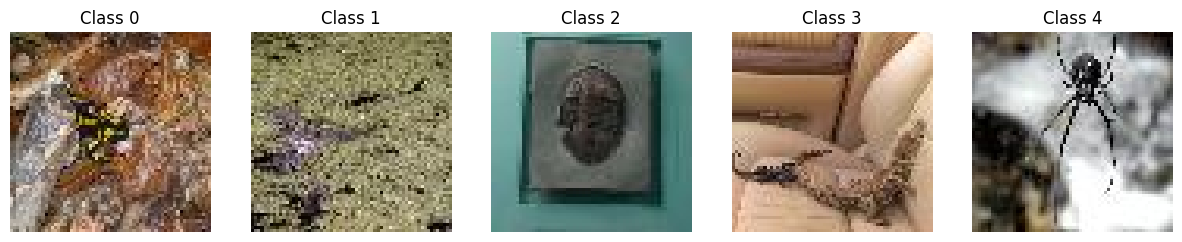


Samples from val split (different classes):


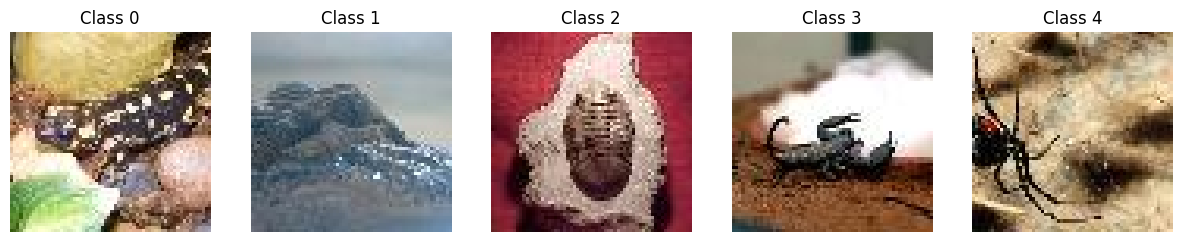


Samples from test split (different classes):


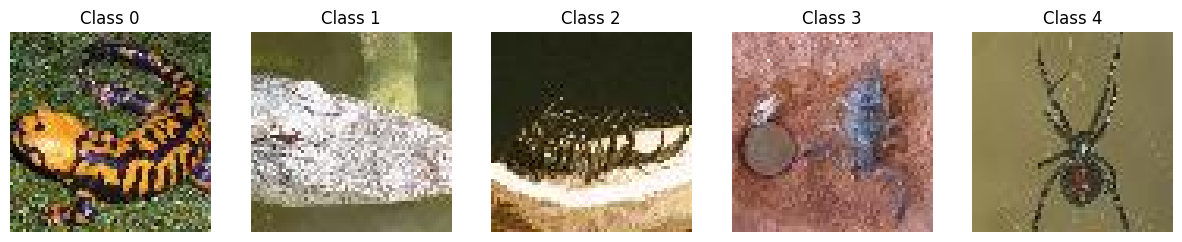

In [14]:
#  Function to visualize sample images from different classes
def visualize_samples_diff_classes(data_list, split_name, num_classes=5):
    """
    Display one sample image from each of several classes in the dataset split.

    Args:
        data_list (list): List of tuples (image_path, label)
        split_name (str): Name of the dataset split ('train', 'val', or 'test')
        num_classes (int): Number of different classes to display
    """
    print(f"\nSamples from {split_name} split (different classes):")

    # Dictionary to store one sample image per class
    class_to_sample = {}
    for img_path, label in data_list:
        # Save the first image encountered for each class
        if label not in class_to_sample:
            class_to_sample[label] = img_path
        # Stop once we have samples for the requested number of classes
        if len(class_to_sample) >= num_classes:
            break

    # Create a horizontal subplot to display images side by side
    fig, axes = plt.subplots(1, len(class_to_sample), figsize=(15,3))

    # Loop over selected classes and display their images
    for i, (label, img_path) in enumerate(class_to_sample.items()):
        # Load image
        img = Image.open(img_path).convert('RGB')
        # Display image
        axes[i].imshow(img)
        # Show class label as title
        axes[i].set_title(f"Class {label}")
        # Hide axes for cleaner visualization
        axes[i].axis('off')

    # Render the figure
    plt.show()

#  Visualize 5 sample images from different classes for each split
visualize_samples_diff_classes(train_data, 'train', num_classes=5)
visualize_samples_diff_classes(val_data, 'val', num_classes=5)
visualize_samples_diff_classes(test_data, 'test', num_classes=5)


## Verifying if train, valid, and test splits have the same 100 classes

In [12]:
#  Check unique classes present in each dataset split
# This helps verify that all splits contain the expected set of classes

# Extract unique labels from each split using a set
# Unique classes in training set
train_classes = set(label for _, label in train_data)

# Unique classes in validation set
val_classes   = set(label for _, label in val_data)

# Unique classes in test set
test_classes  = set(label for _, label in test_data)

# Print the sorted list of classes for each split
# Sorting makes it easier to compare across splits and verify consistency
print(f"Unique classes in train: {sorted(train_classes)}")
print(f"Unique classes in val:   {sorted(val_classes)}")
print(f"Unique classes in test:  {sorted(test_classes)}")


Unique classes in train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Unique classes in val:   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Unique classes in test:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 

In [13]:
# Verifying all splits contain the same classes
assert train_classes == val_classes == test_classes, "Mismatch in classes across splits!"
print("All splits have the same 100 classes.")

All splits have the same 100 classes.
